# SkillNexis Machine Learning & AI Internship
## Week 4 – Major Project: Heart Disease Prediction

### Objective
To predict whether a patient is likely to have heart disease using Machine Learning.

### Workflow
- Data Cleaning
- Feature Scaling
- Logistic Regression
- Decision Tree
- Model Evaluation
- Confusion Matrix
- ROC Curve

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
print("Column Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (303, 13)
Target shape: (303,)

Target values:
target
1    165
0    138
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (242, 13)
Testing data: (61, 13)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(random_state=42)


lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 80.33 %


In [8]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)

print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))

print("\nConfusion Matrix:")
print(cm)

Precision: 0.77
Recall: 0.91

Confusion Matrix:
[[19  9]
 [ 3 30]]


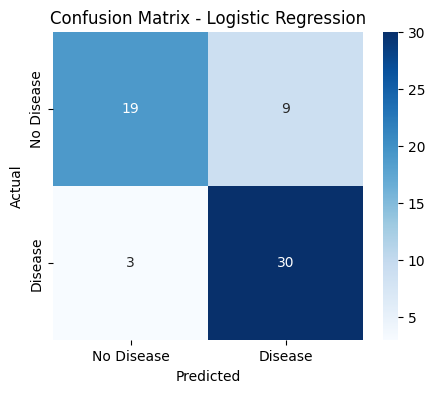

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

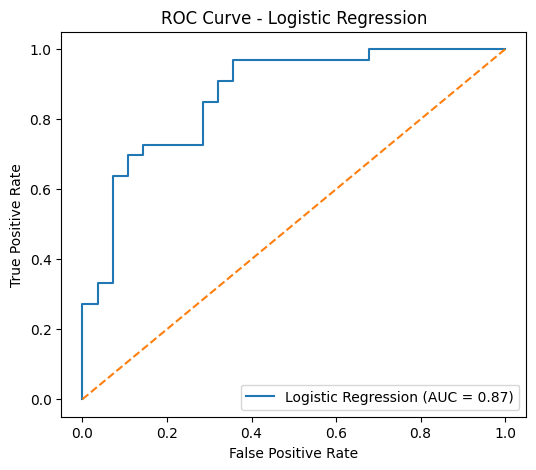

AUC: 0.87


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC:", round(auc, 2))

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)


dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:",
      round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 70.49 %


In [12]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_cm = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree Precision:", round(dt_precision, 2))
print("Decision Tree Recall:", round(dt_recall, 2))

print("\nDecision Tree Confusion Matrix:")
print(dt_cm)

Decision Tree Precision: 0.7
Decision Tree Recall: 0.79

Decision Tree Confusion Matrix:
[[17 11]
 [ 7 26]]


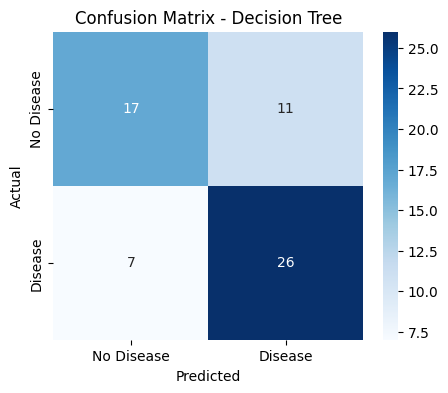

In [13]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [14]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_accuracy, dt_accuracy],
    "Precision": [precision, dt_precision],
    "Recall": [recall, dt_recall]
})

results["Accuracy"] = results["Accuracy"].round(2)
results["Precision"] = results["Precision"].round(2)
results["Recall"] = results["Recall"].round(2)

results

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.8,0.77,0.91
1,Decision Tree,0.7,0.70,0.79


In [15]:
import joblib

joblib.dump(lr_model, "heart_disease_model.pkl")
joblib.dump(scaler, "heart_disease_scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [16]:

loaded_model = joblib.load("heart_disease_model.pkl")
loaded_scaler = joblib.load("heart_disease_scaler.pkl")

X_test_loaded = loaded_scaler.transform(X_test)

loaded_predictions = loaded_model.predict(X_test_loaded)

print("Model loaded successfully!")
print("First 10 predictions:")
print(loaded_predictions[:10])

Model loaded successfully!
First 10 predictions:
[1 1 0 1 1 0 1 1 1 1]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:

new_patient = X.iloc[[0]]

new_patient_scaled = loaded_scaler.transform(new_patient)

prediction = loaded_model.predict(new_patient_scaled)

if prediction[0] == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

Prediction: Heart Disease


In [19]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:",
      round(cv_scores.mean() * 100, 2), "%")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-Validation Scores:
[0.81967213 0.86885246 0.85245902 0.85       0.75      ]

Mean CV Accuracy: 82.82 %


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [20]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 80.33 %


In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm = SVC()

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:",
      round(grid_search.best_score_ * 100, 2), "%")

Best Parameters: {'C': 1, 'kernel': 'linear'}
Best CV Accuracy: 83.93 %


In [23]:
best_svm = grid_search.best_estimator_

y_pred_svm = best_svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")
print("SVM Precision:", round(svm_precision, 2))
print("SVM Recall:", round(svm_recall, 2))

SVM Accuracy: 78.69 %
SVM Precision: 0.75
SVM Recall: 0.91


In [24]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        dt_precision,
        svm_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        dt_recall,
        svm_recall
    ]
})

final_results["Accuracy"] = (
    final_results["Accuracy"] * 100
).round(2)

final_results["Precision"] = (
    final_results["Precision"]
).round(2)

final_results["Recall"] = (
    final_results["Recall"]
).round(2)

final_results


,Model,Accuracy,Precision,Recall
0,Logistic Regression,80.33,0.77,0.91
1,Decision Tree,70.49,0.70,0.79
2,SVM,78.69,0.75,0.91


## Conclusion

In this project, a Heart Disease Prediction system was developed using Machine Learning.

The dataset contained 303 patient records and 13 input features. The data was checked for missing values and no missing values were found. Feature scaling was performed using StandardScaler.

Three classification models were evaluated:
- Logistic Regression
- Decision Tree
- Support Vector Machine (SVM)

The models were evaluated using accuracy, precision, recall, and confusion matrices. A ROC curve was also created for Logistic Regression, with an AUC of 0.87.

5-fold cross-validation was performed for Logistic Regression, giving a mean accuracy of 82.82%.

GridSearchCV was also applied to SVM. The best parameters were C = 1 and kernel = linear, with a cross-validation accuracy of 83.93%.

The trained Logistic Regression model and StandardScaler were saved using joblib and successfully loaded for prediction.

This project demonstrates a complete Machine Learning workflow from data preparation and model training to evaluation, optimization, model saving, and prediction.